In [14]:
DIRECTORY = "tmp/"


In [15]:
import os

logfiles = []

for folder in os.listdir(DIRECTORY):
    for file in os.listdir(os.path.join(DIRECTORY, folder)):
        if file.endswith(".log"):
            log_file_path = os.path.join(DIRECTORY, folder, file)
            logfiles.append(log_file_path)

logfiles

['tmp/hadypxr090/train.log',
 'tmp/s57sd54jkz/train.log',
 'tmp/2kwyqrcm85/train.log',
 'tmp/gl98yloi5x/train.log',
 'tmp/4jcb0dbjyy/train.log',
 'tmp/diu6i2o9b4/train.log',
 'tmp/eiaa5j0s2a/train.log',
 'tmp/wnwjbxmd0t/train.log',
 'tmp/atqm70a2oi/train.log',
 'tmp/hruztap7h5/train.log',
 'tmp/vi27vtu89n/train.log',
 'tmp/xb8o77ep2s/train.log',
 'tmp/9eohrvlqfv/train.log',
 'tmp/ocixdo1nau/train.log',
 'tmp/wd670rxs81/train.log',
 'tmp/97o117bijs/train.log',
 'tmp/1uss61rotq/train.log',
 'tmp/u9aczfm6zj/train.log',
 'tmp/6gk8vnoyet/train.log',
 'tmp/4gexq46qda/train.log',
 'tmp/wojquf32ta/train.log',
 'tmp/j7g814nqyt/train.log',
 'tmp/j2dnazpky8/train.log',
 'tmp/1t5sgopbz7/train.log',
 'tmp/hplu3s9t0d/train.log',
 'tmp/y4okbddeqo/train.log',
 'tmp/ivxjg1mncr/train.log',
 'tmp/5id5icjp4w/train.log',
 'tmp/6r286eswe4/train.log',
 'tmp/atgjlqqats/train.log',
 'tmp/4iw9l5v1n4/train.log',
 'tmp/gecssduhdh/train.log',
 'tmp/9bj0kx222r/train.log',
 'tmp/c8qww44tz7/train.log',
 'tmp/jcmlb6ni

In [16]:
import re

def get_params(log_file_path):
    with open(log_file_path, 'r') as log_file:
        log_data = log_file.read()
    pattern = re.compile(r'(\w+):\s*(.+)')

    params = {}
    for match in pattern.finditer(log_data):
        key, value = match.groups()
        
        # If the value can be interpreted as a number (int or float), convert it
        if value.lower() in ['true', 'false']:
            value = value.lower() == 'true'
        elif re.match(r'^\d+(\.\d+)?$', value):  # If the value is a number (integer or float)
            value = float(value) if '.' in value else int(value)
        
        # Add to the dictionary
        params[key] = value
    return params


In [17]:
import re
import json

def get_training_testing_steps(log_file_path):
    training_steps = []
    testing_steps = []

    log_pattern = re.compile(r'__log:\{(.*?)\}')  # Matches everything between __log:{...}

    with open(log_file_path, 'r') as log_file:
        for line in log_file:
            match = log_pattern.search(line)
            if match:
                log_data = match.group(1) 
                try:
                    log_json = json.loads('{' + log_data + '}')
                    if 'train_acc' in log_json:  # This indicates a training step
                        training_steps.append(log_json)
                    elif 'test_acc_ema' in log_json:  # This indicates a testing step
                        testing_steps.append(log_json)
                except json.JSONDecodeError:
                    print(f"Error decoding JSON in line: {line.strip()}")

    return training_steps, testing_steps

log_file_path = 'tmp/6gk8vnoyet/train.log'
training_steps, testing_steps = get_training_testing_steps(log_file_path)
print(training_steps)

[{'nb_steps': 20, 'train_acc': 0.17161747699930427, 'loss': 2.2396337196302545, 'grad_sample_gradients_norms': 11.671040291619823, 'grad_sample_gradients_norms_lowerC': 0.0}, {'nb_steps': 40, 'train_acc': 0.24914960413094583, 'loss': 2.1085805913369433, 'grad_sample_gradients_norms': 10.865665763428831, 'grad_sample_gradients_norms_lowerC': 0.0}, {'nb_steps': 60, 'train_acc': 0.2582674895595204, 'loss': 2.10630708607797, 'grad_sample_gradients_norms': 11.297015499481978, 'grad_sample_gradients_norms_lowerC': 0.0005744925315970893}, {'nb_steps': 80, 'train_acc': 0.33291058995238887, 'loss': 1.8896698056881156, 'grad_sample_gradients_norms': 10.187074867046833, 'grad_sample_gradients_norms_lowerC': 0.0015794669299111549}, {'nb_steps': 100, 'train_acc': 0.36264116908783656, 'loss': 1.8224159106375553, 'grad_sample_gradients_norms': 11.197723247030538, 'grad_sample_gradients_norms_lowerC': 0.0027944111776447107}, {'nb_steps': 120, 'train_acc': 0.3863216232019323, 'loss': 1.7899618212447161

In [18]:
log_file_path = 'tmp/6gk8vnoyet/train.log'
experiment1 = get_params(log_file_path)
training_steps, testing_steps = get_training_testing_steps(log_file_path)
experiment1["training_steps"] = training_steps
experiment1["testing_steps"] = testing_steps
experiment1

{'03': '57:51 - 0:00:00 - Running command: python cifar10.py --batch_size 256 --ref_nb_steps 500 --ref_B 4096 --ref_noise 3 --transform 16 --data_root data --experiment 1',
 'WRN_k': 4,
 'batch_size': 256,
 'command': 'python cifar10.py --batch_size 256 --ref_nb_steps 500 --ref_B 4096 --ref_noise 3 --transform 16 --data_root data --experiment 1 --exp_id "6gk8vnoyet"',
 'data_root': 'data',
 'debug_slurm': False,
 'delta': '1e-05',
 'dump_path': '/tmp/6gk8vnoyet',
 'exp_id': '6gk8vnoyet',
 'exp_name': 'bypass',
 'experiment': 1,
 'freq_log': 20,
 'freq_log_val': 100,
 'global_rank': 0,
 'init': 0,
 'is_master': True,
 'is_slurm_job': False,
 'local_rank': 0,
 'lr': 4,
 'master_port': '-1',
 'max_per_sample_grad_norm': 1,
 'max_physical_batch_size': 128,
 'momentum': 0,
 'multi_gpu': False,
 'multi_node': False,
 'n_gpu_per_node': 1,
 'n_nodes': 1,
 'nb_groups': 16,
 'node_id': 0,
 'order1': 0,
 'order2': 0,
 'poisson_sampling': True,
 'proportion': 1,
 'ref_B': 4096,
 'ref_nb_steps': 50

In [19]:
experiments = []
for log_file_path in logfiles:
    exp = get_params(log_file_path)
    training_steps, testing_steps = get_training_testing_steps(log_file_path)
    exp["training_steps"] = training_steps
    exp["testing_steps"] = testing_steps
    experiments.append(exp)

In [20]:
import pandas as pd
df_experiments = pd.DataFrame(experiments)
df_experiments.columns

Index(['20', 'WRN_k', 'batch_size', 'command', 'data_root', 'debug_slurm',
       'delta', 'dump_path', 'exp_id', 'exp_name', 'experiment', 'freq_log',
       'freq_log_val', 'global_rank', 'init', 'is_master', 'is_slurm_job',
       'local_rank', 'lr', 'master_port', 'max_per_sample_grad_norm',
       'max_physical_batch_size', 'momentum', 'multi_gpu', 'multi_node',
       'n_gpu_per_node', 'n_nodes', 'nb_groups', 'node_id', 'order1', 'order2',
       'poisson_sampling', 'proportion', 'ref_B', 'ref_nb_steps', 'ref_noise',
       'transform', 'world_size', 'training_steps', 'testing_steps', '21',
       '17', 'noise_decay', 'noise_scheduler', '18', '19', '22', '23', '00',
       '01', '13', '14', '15', '03', '04', '05', '06', '07', '08', '02',
       'save_gradients', '09', '10', '11', '12'],
      dtype='object')

In [21]:
df_experiments["noise_scheduler"]

0               NaN
1               NaN
2       exponential
3              None
4               NaN
5     gradientratio
6       exponential
7               NaN
8              None
9       exponential
10      exponential
11              NaN
12    gradientratio
13      exponential
14      exponential
15      exponential
16             None
17              NaN
18              NaN
19             None
20      exponential
21     gradientrule
22             None
23              NaN
24              NaN
25              NaN
26              NaN
27              NaN
28              NaN
29              NaN
30      exponential
31    gradientratio
32              NaN
33      exponential
34              NaN
35      exponential
36              NaN
37              NaN
Name: noise_scheduler, dtype: object

In [22]:
df_experiments["training_steps"][1]

[{'nb_steps': 20,
  'train_acc': 0.16411603682207854,
  'loss': 2.2895458078235738,
  'grad_sample_gradients_norms': 12.015830574372567,
  'grad_sample_gradients_norms_lowerC': 0.0},
 {'nb_steps': 40,
  'train_acc': 0.25524050918012603,
  'loss': 2.0838815107897593,
  'grad_sample_gradients_norms': 10.74943872925007,
  'grad_sample_gradients_norms_lowerC': 0.0}]

## Experiments about the Added Noise

In [23]:
df_noise_experiments = df_experiments[df_experiments.ref_nb_steps == 500]
df_noise_experiments

,20,WRN_k,batch_size,command,data_root,debug_slurm,delta,dump_path,exp_id,exp_name,...,05,06,07,08,02,save_gradients,09,10,11,12
7,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/wnwjbxmd0t,wnwjbxmd0t,bypass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/u9aczfm6zj,u9aczfm6zj,bypass,...,NaN,"57:03 - 0:06:32 - __log:{""nb_steps"": 20, ""trai...","58:35 - 1:08:04 - __log:{""test_acc_ema"": 0.531...","58:55 - 2:08:24 - __log:{""nb_steps"": 380, ""tra...",NaN,NaN,"42:58 - 2:52:27 - __log:{""final_train_acc_non_...",NaN,NaN,NaN
18,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/6gk8vnoyet,6gk8vnoyet,bypass,...,"59:57 - 2:02:06 - __log:{""nb_steps"": 360, ""tra...","50:25 - 2:52:34 - __log:{""final_train_acc_non_...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/y4okbddeqo,y4okbddeqo,bypass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"55:06 - 0:19:57 - __log:{""nb_steps"": 60, ""trai..."
28,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/6r286eswe4,6r286eswe4,bypass,...,NaN,NaN,NaN,NaN,NaN,NaN,"56:20 - 0:13:17 - __log:{""nb_steps"": 40, ""trai...","57:31 - 1:14:27 - __log:{""nb_steps"": 220, ""tra...","59:16 - 2:16:12 - __log:{""test_acc_ema"": 0.613...","35:03 - 2:51:59 - __log:{""final_train_acc_non_..."
36,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/rub43ift2f,rub43ift2f,bypass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
df_noise_experiments["training_steps"]

7     [{'nb_steps': 20, 'train_acc': 0.1561626843420...
17    [{'nb_steps': 20, 'train_acc': 0.1705191312033...
18    [{'nb_steps': 20, 'train_acc': 0.1716174769993...
25    [{'nb_steps': 20, 'train_acc': 0.1929346479705...
28    [{'nb_steps': 20, 'train_acc': 0.1878313788520...
36    [{'nb_steps': 20, 'train_acc': 0.1855279714709...
Name: training_steps, dtype: object

In [25]:
df_noise_experiments["ref_noise"]

7     1.0
17    3.0
18    3.0
25    1.0
28    3.0
36    1.0
Name: ref_noise, dtype: float64

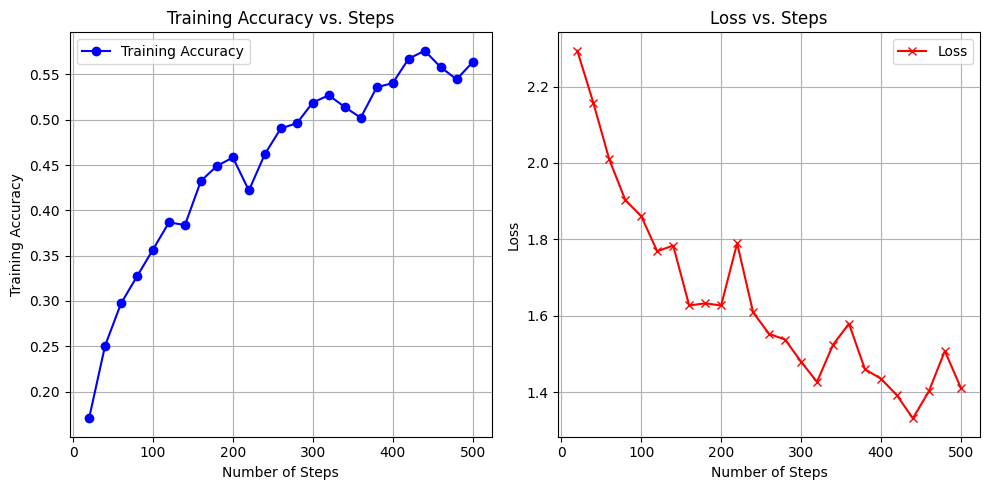

In [26]:
import matplotlib.pyplot as plt

experiment_idx = 1
data = df_noise_experiments.iloc[experiment_idx]["training_steps"]

# Extracting values for plotting
steps = [entry['nb_steps'] for entry in data]
train_acc = [entry['train_acc'] for entry in data]
loss = [entry['loss'] for entry in data]

# Create the plot
plt.figure(figsize=(10, 5))

# Plot training accuracy
plt.subplot(1, 2, 1)
plt.plot(steps, train_acc, label='Training Accuracy', color='b', marker='o')
plt.xlabel('Number of Steps')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy vs. Steps')
plt.grid(True)
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(steps, loss, label='Loss', color='r', marker='x')
plt.xlabel('Number of Steps')
plt.ylabel('Loss')
plt.title('Loss vs. Steps')
plt.grid(True)
plt.legend()

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()


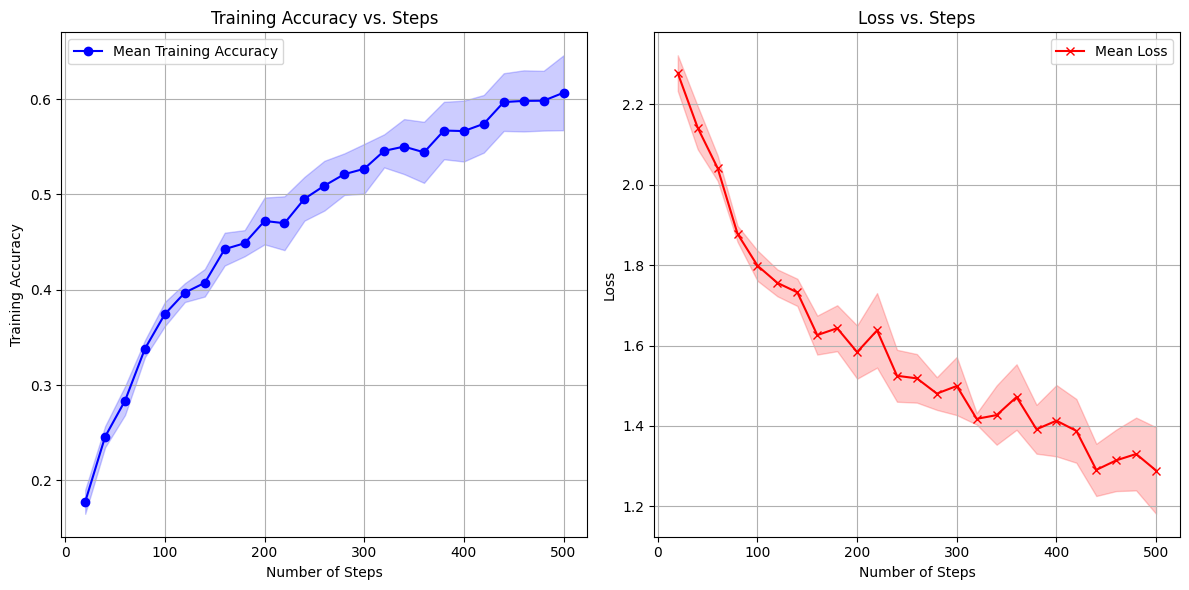

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Initialize lists to store training accuracy and loss at each step
all_steps = []
all_train_acc = {}
all_loss = {}

# Loop through all experiments
for idx in range(len(df_noise_experiments)):

    experiment = df_noise_experiments.iloc[idx]
    training_steps = experiment["training_steps"]
    
    # Extract steps, train_acc, and loss for each experiment
    steps = [entry['nb_steps'] for entry in training_steps]
    train_acc = [entry['train_acc'] for entry in training_steps]
    loss = [entry['loss'] for entry in training_steps]
    
    # For each unique step, accumulate the train_acc and loss values
    for step, acc, l in zip(steps, train_acc, loss):
        if step not in all_steps:
            all_steps.append(step)
        
        if step not in all_train_acc:
            all_train_acc[step] = []
        if step not in all_loss:
            all_loss[step] = []
        
        all_train_acc[step].append(acc)
        all_loss[step].append(l)

# Sort the steps (optional, depending on how the steps are ordered)
all_steps = sorted(all_steps)

# Calculate the mean and standard deviation for each step
mean_train_acc = []
std_train_acc = []
mean_loss = []
std_loss = []

for step in all_steps:
    mean_train_acc.append(np.mean(all_train_acc[step]))
    std_train_acc.append(np.std(all_train_acc[step]))
    mean_loss.append(np.mean(all_loss[step]))
    std_loss.append(np.std(all_loss[step]))

# Create the plot
plt.figure(figsize=(12, 6))

# Plot training accuracy
plt.subplot(1, 2, 1)
plt.plot(all_steps, mean_train_acc, label='Mean Training Accuracy', color='b', marker='o')
plt.fill_between(all_steps, np.array(mean_train_acc) - np.array(std_train_acc), 
                 np.array(mean_train_acc) + np.array(std_train_acc), color='b', alpha=0.2)
plt.xlabel('Number of Steps')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy vs. Steps')
plt.grid(True)
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(all_steps, mean_loss, label='Mean Loss', color='r', marker='x')
plt.fill_between(all_steps, np.array(mean_loss) - np.array(std_loss), 
                 np.array(mean_loss) + np.array(std_loss), color='r', alpha=0.2)
plt.xlabel('Number of Steps')
plt.ylabel('Loss')
plt.title('Loss vs. Steps')
plt.grid(True)
plt.legend()

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()


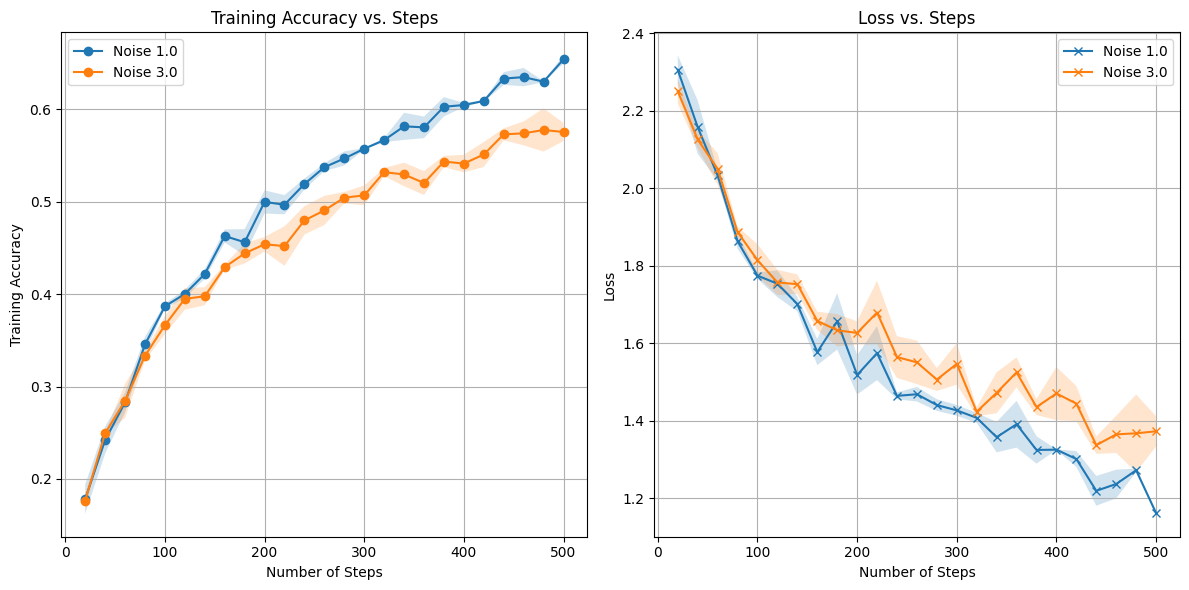

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Initialize lists to store training accuracy and loss at each step, grouped by ref_noise
all_steps = []
all_train_acc = {}
all_loss = {}
ref_noise_groups = {}

# Loop through all experiments
for idx in range(len(df_noise_experiments)):

    experiment = df_noise_experiments.iloc[idx]
    ref_noise = experiment["ref_noise"]
    training_steps = experiment["training_steps"]
    
    # Extract steps, train_acc, and loss for each experiment
    steps = [entry['nb_steps'] for entry in training_steps]
    train_acc = [entry['train_acc'] for entry in training_steps]
    loss = [entry['loss'] for entry in training_steps]
    
    # For each unique step, accumulate the train_acc and loss values grouped by ref_noise
    for step, acc, l in zip(steps, train_acc, loss):
        if step not in all_steps:
            all_steps.append(step)
        
        if ref_noise not in ref_noise_groups:
            ref_noise_groups[ref_noise] = {"train_acc": {}, "loss": {}}
        
        if step not in ref_noise_groups[ref_noise]["train_acc"]:
            ref_noise_groups[ref_noise]["train_acc"][step] = []
        if step not in ref_noise_groups[ref_noise]["loss"]:
            ref_noise_groups[ref_noise]["loss"][step] = []
        
        ref_noise_groups[ref_noise]["train_acc"][step].append(acc)
        ref_noise_groups[ref_noise]["loss"][step].append(l)

# Sort the steps (optional, depending on how the steps are ordered)
all_steps = sorted(all_steps)

# Create the plot
plt.figure(figsize=(12, 6))

# Loop through each ref_noise group and calculate mean and std, then plot
for ref_noise, group in ref_noise_groups.items():
    mean_train_acc = []
    std_train_acc = []
    mean_loss = []
    std_loss = []
    
    # Calculate the mean and standard deviation for each step in this group
    for step in all_steps:
        mean_train_acc.append(np.mean(group["train_acc"].get(step, [0])))
        std_train_acc.append(np.std(group["train_acc"].get(step, [0])))
        mean_loss.append(np.mean(group["loss"].get(step, [0])))
        std_loss.append(np.std(group["loss"].get(step, [0])))
    
    # Plot training accuracy with shaded standard deviation
    plt.subplot(1, 2, 1)
    plt.plot(all_steps, mean_train_acc, label=f'Noise {ref_noise}', marker='o')
    plt.fill_between(all_steps, np.array(mean_train_acc) - np.array(std_train_acc), 
                     np.array(mean_train_acc) + np.array(std_train_acc), alpha=0.2)
    
    # Plot loss with shaded standard deviation
    plt.subplot(1, 2, 2)
    plt.plot(all_steps, mean_loss, label=f'Noise {ref_noise}', marker='x')
    plt.fill_between(all_steps, np.array(mean_loss) - np.array(std_loss), 
                     np.array(mean_loss) + np.array(std_loss), alpha=0.2)

# Set labels, titles, and grids
plt.subplot(1, 2, 1)
plt.xlabel('Number of Steps')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy vs. Steps')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.xlabel('Number of Steps')
plt.ylabel('Loss')
plt.title('Loss vs. Steps')
plt.grid(True)
plt.legend()

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()


## Experiments with Deepmind Hyperparameters

In [29]:
df_deepmind_experiments = df_experiments[df_experiments["ref_nb_steps"]==1593]

df_deepmind_experiments[["dump_path", "batch_size", "ref_noise", "training_steps"]]

,dump_path,batch_size,ref_noise,training_steps
2,/tmp/2kwyqrcm85,256,5.0,"[{'nb_steps': 20, 'train_acc': 0.1649662927189..."
3,/tmp/gl98yloi5x,256,5.0,[]
5,/tmp/diu6i2o9b4,256,5.0,"[{'nb_steps': 20, 'train_acc': 0.1765009765475..."
6,/tmp/eiaa5j0s2a,32,5.0,"[{'nb_steps': 20, 'train_acc': 0.1252005828373..."
8,/tmp/atqm70a2oi,256,5.0,[]
9,/tmp/hruztap7h5,32,5.0,[]
10,/tmp/vi27vtu89n,32,5.0,[]
12,/tmp/9eohrvlqfv,256,5.0,"[{'nb_steps': 20, 'train_acc': 0.1779377449573..."
13,/tmp/ocixdo1nau,256,5.0,"[{'nb_steps': 20, 'train_acc': 0.2035629731592..."
14,/tmp/wd670rxs81,32,5.0,"[{'nb_steps': 20, 'train_acc': 0.1298270089285..."


### Experiments with the actual deepmind parameters:
- 2kwyqrcm85 final epsilon: 54.974591425596806
- ocixdo1nau final epsilon: 54.38862450553011 (not max iterations)
- c8qww44tz7 final test epsilon: 54.974591425596806


In [30]:
df_experiments.columns

Index(['20', 'WRN_k', 'batch_size', 'command', 'data_root', 'debug_slurm',
       'delta', 'dump_path', 'exp_id', 'exp_name', 'experiment', 'freq_log',
       'freq_log_val', 'global_rank', 'init', 'is_master', 'is_slurm_job',
       'local_rank', 'lr', 'master_port', 'max_per_sample_grad_norm',
       'max_physical_batch_size', 'momentum', 'multi_gpu', 'multi_node',
       'n_gpu_per_node', 'n_nodes', 'nb_groups', 'node_id', 'order1', 'order2',
       'poisson_sampling', 'proportion', 'ref_B', 'ref_nb_steps', 'ref_noise',
       'transform', 'world_size', 'training_steps', 'testing_steps', '21',
       '17', 'noise_decay', 'noise_scheduler', '18', '19', '22', '23', '00',
       '01', '13', '14', '15', '03', '04', '05', '06', '07', '08', '02',
       'save_gradients', '09', '10', '11', '12'],
      dtype='object')

In [31]:
df_deepmind_experiments.iloc[0][['WRN_k', 'batch_size', 'command', 'data_root', 'debug_slurm',
       'delta', 'dump_path', 'exp_id', 'exp_name', 'experiment', 'freq_log',
       'freq_log_val', 'global_rank', 'init', 'is_master', 'is_slurm_job',
       'local_rank', 'lr', 'master_port', 'max_per_sample_grad_norm',
       'max_physical_batch_size', 'momentum', 'multi_gpu', 'multi_node',
       'n_gpu_per_node', 'n_nodes', 'nb_groups', 'node_id', 'order1', 'order2',
       'poisson_sampling', 'proportion', 'ref_B', 'ref_nb_steps', 'ref_noise',
       'transform', 'world_size', 'training_steps', 'testing_steps', 'noise_decay', 'noise_scheduler']]

WRN_k                                                                       4
batch_size                                                                256
command                     python cifar10.py --batch_size 256 --ref_nb_st...
data_root                                                                data
debug_slurm                                                             False
delta                                                                   1e-05
dump_path                                                     /tmp/2kwyqrcm85
exp_id                                                             2kwyqrcm85
exp_name                                                               bypass
experiment                                                                  1
freq_log                                                                   20
freq_log_val                                                              100
global_rank                                                     

In [32]:
df_deepmind_experiments["exp_id"]

2     2kwyqrcm85
3     gl98yloi5x
5     diu6i2o9b4
6     eiaa5j0s2a
8     atqm70a2oi
9     hruztap7h5
10    vi27vtu89n
12    9eohrvlqfv
13    ocixdo1nau
14    wd670rxs81
15    97o117bijs
16    1uss61rotq
19    4gexq46qda
20    wojquf32ta
21    j7g814nqyt
22    j2dnazpky8
23    1t5sgopbz7
30    4iw9l5v1n4
31    gecssduhdh
33    c8qww44tz7
35    ijodnfs4q9
Name: exp_id, dtype: object

In [33]:
df_deepmind_experiments[df_deepmind_experiments["exp_id"]=="2kwyqrcm85"]["training_steps"].values[0]

[{'nb_steps': 20,
  'train_acc': 0.16496629271895474,
  'loss': 2.305430300388464,
  'grad_sample_gradients_norms': 12.010143782702155,
  'grad_sample_gradients_norms_lowerC': 0.0,
  'epsilon': 15.611442961399858,
  'noise_multiplier': 0.3125},
 {'nb_steps': 40,
  'train_acc': 0.256680737538357,
  'loss': 2.0843292157710818,
  'grad_sample_gradients_norms': 10.94531560622693,
  'grad_sample_gradients_norms_lowerC': 0.0,
  'epsilon': 17.776338358372534,
  'noise_multiplier': 0.3125},
 {'nb_steps': 60,
  'train_acc': 0.282576887085594,
  'loss': 2.0749440937254042,
  'grad_sample_gradients_norms': 10.474141485004568,
  'grad_sample_gradients_norms_lowerC': 0.0,
  'epsilon': 19.263661125124923,
  'noise_multiplier': 0.3125},
 {'nb_steps': 80,
  'train_acc': 0.3489825159612749,
  'loss': 1.8344038771552307,
  'grad_sample_gradients_norms': 10.734693406884952,
  'grad_sample_gradients_norms_lowerC': 0.0007720517274657402,
  'epsilon': 20.75098389187731,
  'noise_multiplier': 0.3125},
 {'nb_

In [34]:
data = df_deepmind_experiments.iloc[0]["testing_steps"]
data

[{'test_acc_ema': 0.4345703125, 'train_acc_ema': 0.4227189592965613},
 {'test_acc_ema': 0.497265625, 'train_acc_ema': 0.500140849068553},
 {'test_acc_ema': 0.52177734375, 'train_acc_ema': 0.5257967480443151},
 {'test_acc_ema': 0.548828125, 'train_acc_ema': 0.5536519223628534},
 {'test_acc_ema': 0.56904296875, 'train_acc_ema': 0.5831308404226737},
 {'test_acc_ema': 0.5849609375, 'train_acc_ema': 0.598904833055076},
 {'test_acc_ema': 0.60400390625, 'train_acc_ema': 0.6165742428863733},
 {'test_acc_ema': 0.61923828125, 'train_acc_ema': 0.6305940943800623},
 {'test_acc_ema': 0.63212890625, 'train_acc_ema': 0.6426650623873911},
 {'test_acc_ema': 0.64169921875, 'train_acc_ema': 0.6520930386473153},
 {'test_acc_ema': 0.64912109375, 'train_acc_ema': 0.6607409760409384},
 {'test_acc_ema': 0.65439453125, 'train_acc_ema': 0.6651847746800857},
 {'test_acc_ema': 0.66044921875, 'train_acc_ema': 0.6747829378577616},
 {'test_acc_ema': 0.6662109375, 'train_acc_ema': 0.6830850950856467},
 {'test_acc_ema

/var/folders/9l/2lhc2hnd6px5hd0bxlsy1rh80000gn/T/ipykernel_90740/3433337540.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("coolwarm", 2)


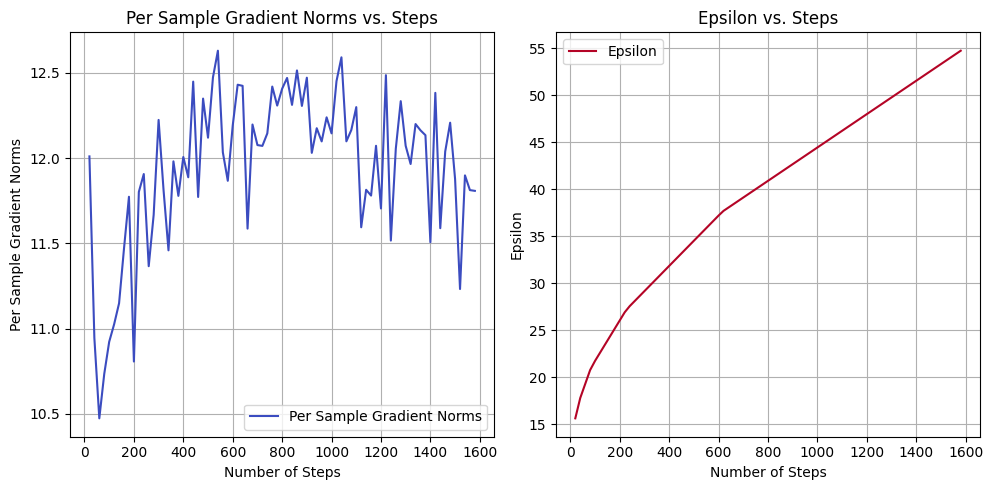

In [47]:
import matplotlib.pyplot as plt

def plot_gradient_epsilon(data, save_file):

    # Extracting values for plotting
    steps = [entry['nb_steps'] for entry in data]
    grad_sample_gradients_norms = [entry['grad_sample_gradients_norms'] for entry in data]
    epsilon = [entry['epsilon'] for entry in data]

    # Create the plot
    fig = plt.figure(figsize=(10, 5))

    from matplotlib import cm
    colormap = cm.get_cmap("coolwarm", 2)
    colors = [colormap(i) for i in range(2)]

    # Plot training accuracy
    plt.subplot(1, 2, 1)
    plt.plot(steps, grad_sample_gradients_norms, label='Per Sample Gradient Norms', color=colors[0])
    plt.xlabel('Number of Steps')
    plt.ylabel('Per Sample Gradient Norms')
    plt.title('Per Sample Gradient Norms vs. Steps')
    plt.grid(True)
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(steps, epsilon, label='Epsilon', color=colors[1])
    plt.xlabel('Number of Steps')
    plt.ylabel('Epsilon')
    plt.title('Epsilon vs. Steps')
    plt.grid(True)
    plt.legend()

    # Adjust layout to avoid overlap
    plt.tight_layout()

    # Show the plot
    plt.show()
    fig.savefig(save_file)

experiment_idx = 0
#data = df_deepmind_experiments.iloc[0]["training_steps"]
data = df_deepmind_experiments[df_deepmind_experiments["exp_id"]=="2kwyqrcm85"]["training_steps"].values[0]

plot_gradient_epsilon(data, "sample_plot_eps.pdf")

/var/folders/9l/2lhc2hnd6px5hd0bxlsy1rh80000gn/T/ipykernel_90740/2851702510.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("coolwarm", 2)


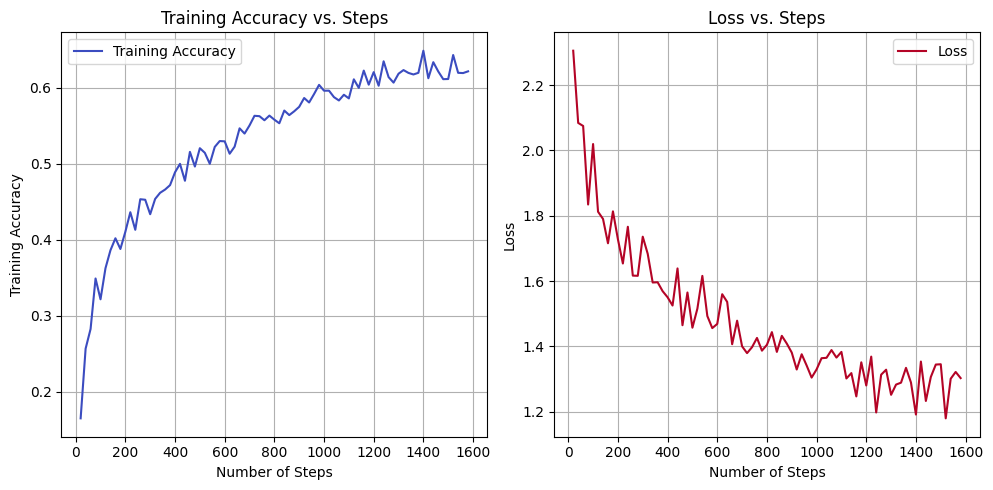

In [37]:
import matplotlib.pyplot as plt

def plot_training(data, save_file):

    # Extracting values for plotting
    steps = [entry['nb_steps'] for entry in data]
    train_acc = [entry['train_acc'] for entry in data]
    loss = [entry['loss'] for entry in data]

    # Create the plot
    fig = plt.figure(figsize=(10, 5))

    from matplotlib import cm
    colormap = cm.get_cmap("coolwarm", 2)
    colors = [colormap(i) for i in range(2)]

    # Plot training accuracy
    plt.subplot(1, 2, 1)
    plt.plot(steps, train_acc, label='Training Accuracy', color=colors[0])
    plt.xlabel('Number of Steps')
    plt.ylabel('Training Accuracy')
    plt.title('Training Accuracy vs. Steps')
    plt.grid(True)
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(steps, loss, label='Loss', color=colors[1])
    plt.xlabel('Number of Steps')
    plt.ylabel('Loss')
    plt.title('Loss vs. Steps')
    plt.grid(True)
    plt.legend()

    # Adjust layout to avoid overlap
    plt.tight_layout()

    # Show the plot
    plt.show()
    fig.savefig(save_file)

experiment_idx = 0
#data = df_deepmind_experiments.iloc[0]["training_steps"]
data = df_deepmind_experiments[df_deepmind_experiments["exp_id"]=="2kwyqrcm85"]["training_steps"].values[0]
plot_training(data, "sample.pdf")

## Experiments with Noise Scheduling

In [38]:
df_experiments.columns

Index(['20', 'WRN_k', 'batch_size', 'command', 'data_root', 'debug_slurm',
       'delta', 'dump_path', 'exp_id', 'exp_name', 'experiment', 'freq_log',
       'freq_log_val', 'global_rank', 'init', 'is_master', 'is_slurm_job',
       'local_rank', 'lr', 'master_port', 'max_per_sample_grad_norm',
       'max_physical_batch_size', 'momentum', 'multi_gpu', 'multi_node',
       'n_gpu_per_node', 'n_nodes', 'nb_groups', 'node_id', 'order1', 'order2',
       'poisson_sampling', 'proportion', 'ref_B', 'ref_nb_steps', 'ref_noise',
       'transform', 'world_size', 'training_steps', 'testing_steps', '21',
       '17', 'noise_decay', 'noise_scheduler', '18', '19', '22', '23', '00',
       '01', '13', '14', '15', '03', '04', '05', '06', '07', '08', '02',
       'save_gradients', '09', '10', '11', '12'],
      dtype='object')

### Gradient Ratio Scheduler

In [39]:
df_experiments[df_experiments["noise_scheduler"]=="gradientratio"]["training_steps"]

5     [{'nb_steps': 20, 'train_acc': 0.1765009765475...
12    [{'nb_steps': 20, 'train_acc': 0.1779377449573...
31    [{'nb_steps': 20, 'train_acc': 0.1888428530759...
Name: training_steps, dtype: object

/var/folders/9l/2lhc2hnd6px5hd0bxlsy1rh80000gn/T/ipykernel_90740/2851702510.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("coolwarm", 2)


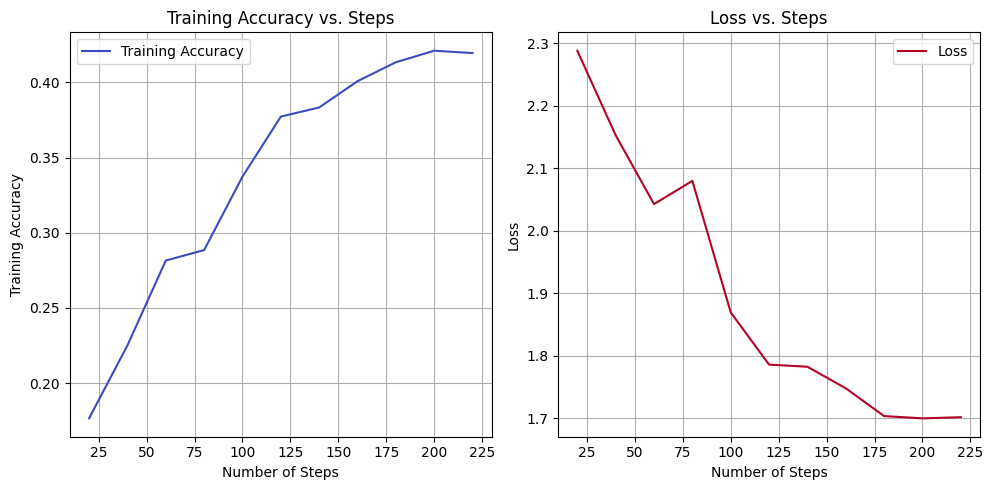

In [42]:
plot_training(df_experiments.iloc[5]["training_steps"], "Gradientratio_exp1.pdf")

/var/folders/9l/2lhc2hnd6px5hd0bxlsy1rh80000gn/T/ipykernel_90740/3433337540.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("coolwarm", 2)


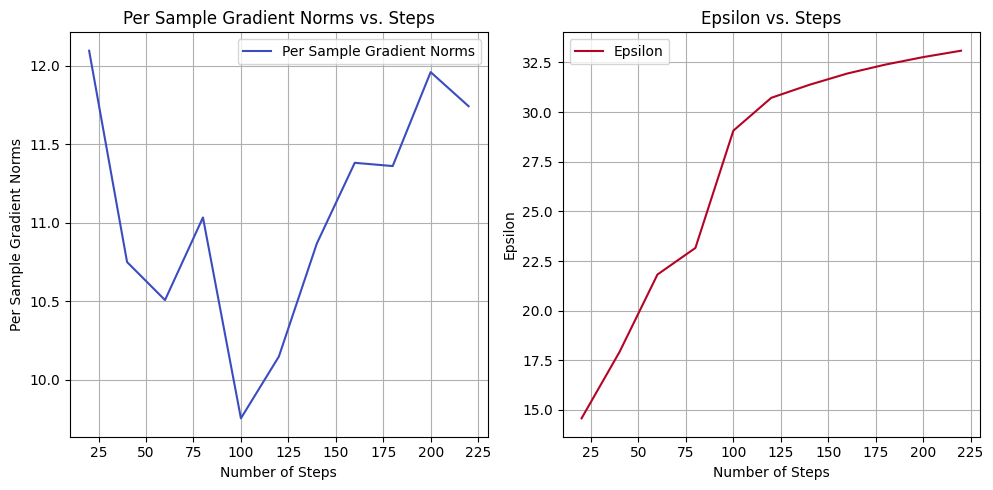

In [48]:
plot_gradient_epsilon(df_experiments.iloc[5]["training_steps"],"")

/var/folders/9l/2lhc2hnd6px5hd0bxlsy1rh80000gn/T/ipykernel_90740/2851702510.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("coolwarm", 2)


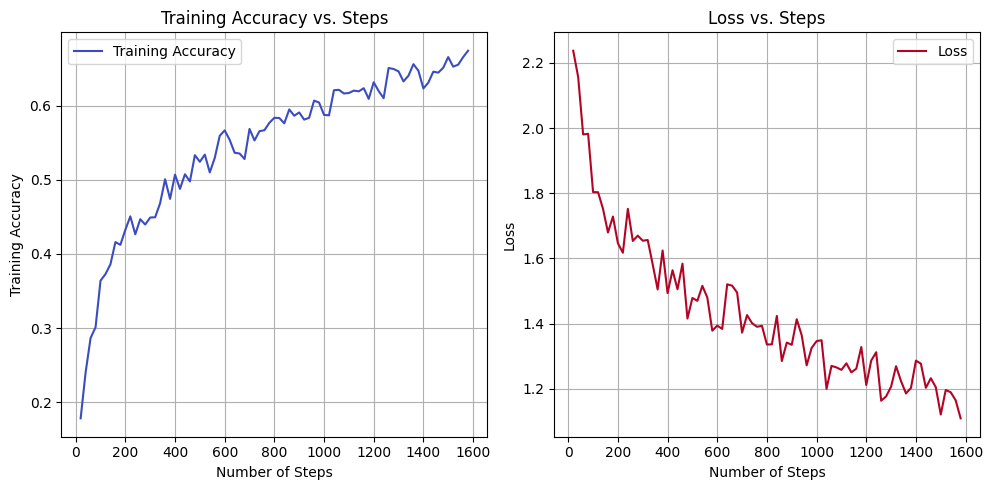

In [43]:
plot_training(df_experiments.iloc[12]["training_steps"], "Gradientratio_exp1.pdf")

/var/folders/9l/2lhc2hnd6px5hd0bxlsy1rh80000gn/T/ipykernel_90740/3433337540.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("coolwarm", 2)


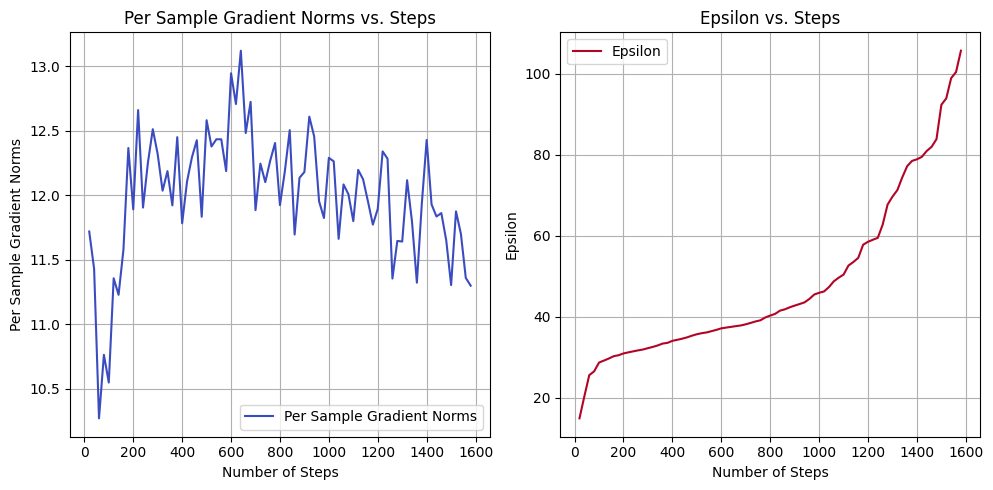

In [49]:
plot_gradient_epsilon(df_experiments.iloc[12]["training_steps"], "")

/var/folders/9l/2lhc2hnd6px5hd0bxlsy1rh80000gn/T/ipykernel_90740/2851702510.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("coolwarm", 2)


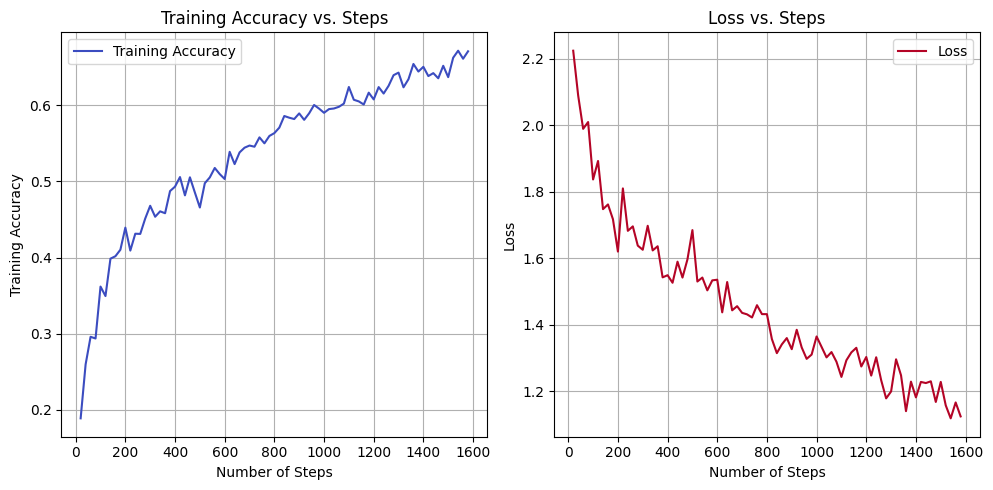

In [44]:
plot_training(df_experiments.iloc[31]["training_steps"], "Gradientratio_exp1.pdf")

/var/folders/9l/2lhc2hnd6px5hd0bxlsy1rh80000gn/T/ipykernel_90740/3433337540.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("coolwarm", 2)


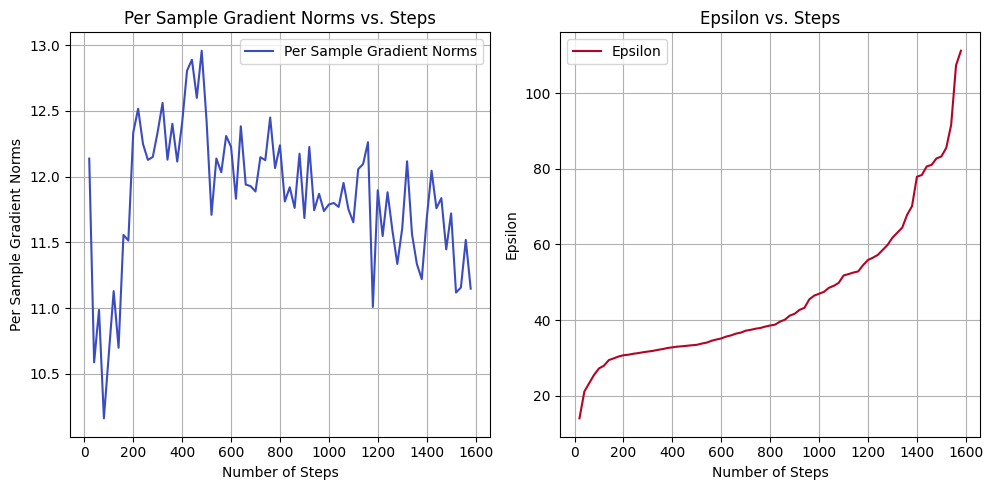

In [50]:
plot_gradient_epsilon(df_experiments.iloc[31]["training_steps"],"")

### Gradient Rule Scheduler

In [45]:
df_experiments[df_experiments["noise_scheduler"]=="gradientrule"]

,20,WRN_k,batch_size,command,data_root,debug_slurm,delta,dump_path,exp_id,exp_name,...,05,06,07,08,02,save_gradients,09,10,11,12
21,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/j7g814nqyt,j7g814nqyt,bypass,...,NaN,NaN,NaN,"57:56 - 0:34:24 - __log:{""nb_steps"": 180, ""tra...",NaN,NaN,"59:43 - 1:36:11 - __log:{""test_acc_ema"": 0.418...","57:58 - 2:34:26 - __log:{""nb_steps"": 820, ""tra...","59:15 - 3:35:43 - __log:{""nb_steps"": 1160, ""tr...","59:14 - 4:35:42 - __log:{""test_acc_ema"": 0.451..."


/var/folders/9l/2lhc2hnd6px5hd0bxlsy1rh80000gn/T/ipykernel_90740/2851702510.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("coolwarm", 2)


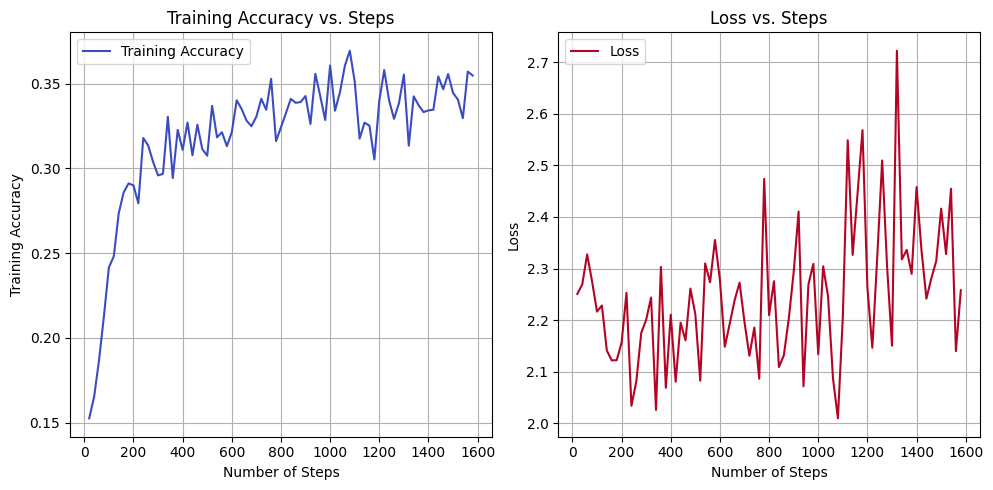

In [52]:
plot_training(df_experiments.iloc[21]["training_steps"],"")

/var/folders/9l/2lhc2hnd6px5hd0bxlsy1rh80000gn/T/ipykernel_90740/3433337540.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("coolwarm", 2)


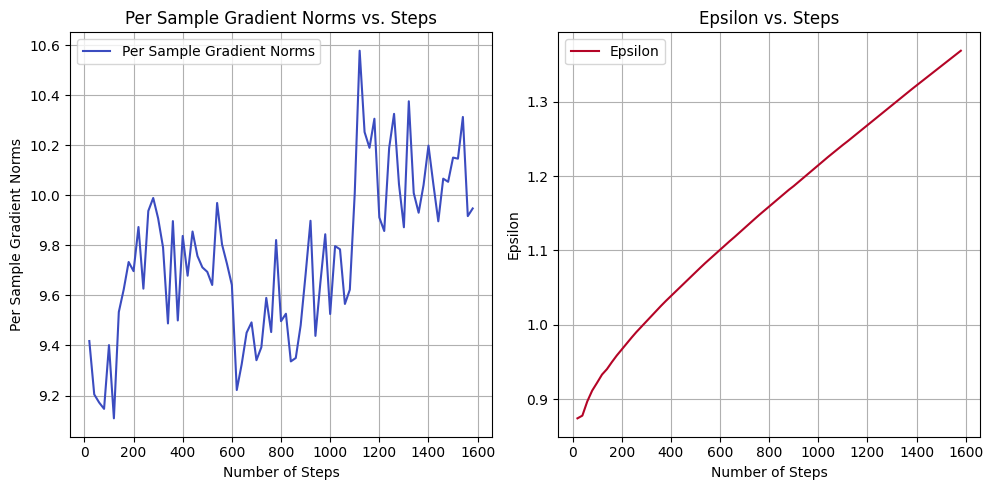

In [53]:
plot_gradient_epsilon(df_experiments.iloc[21]["training_steps"],"")

## Overview of Schedulers vs. no Schedulers

In [87]:
df_experiments["training_steps"].iloc[12]

[{'nb_steps': 20,
  'train_acc': 0.17793774495734282,
  'loss': 2.237616255385646,
  'grad_sample_gradients_norms': 11.717699323120701,
  'grad_sample_gradients_norms_lowerC': 0.0,
  'epsilon': 14.912921668591864,
  'noise_multiplier': 0.3149614635784579,
  'grad_gradients_median': 11.232798099517822,
  'grad_gradients_max': 28.066795349121094,
  'grad_gradients_min': 4.991431713104248},
 {'nb_steps': 40,
  'train_acc': 0.23994504289956148,
  'loss': 2.1566847586282574,
  'grad_sample_gradients_norms': 11.428350203315585,
  'grad_sample_gradients_norms_lowerC': 0.0,
  'epsilon': 20.35709325558483,
  'noise_multiplier': 0.2995062111812969,
  'grad_gradients_median': 10.681313514709473,
  'grad_gradients_max': 37.24916076660156,
  'grad_gradients_min': 1.7596909999847412},
 {'nb_steps': 60,
  'train_acc': 0.28647757377117666,
  'loss': 1.9806068205147085,
  'grad_sample_gradients_norms': 10.270395058548969,
  'grad_sample_gradients_norms_lowerC': 0.0,
  'epsilon': 25.574439111308987,
  '

In [94]:
# Filter the DataFrame
filtered_df = df_experiments[df_experiments["training_steps"].apply(
    lambda steps: any(entry.get('nb_steps') == 1580 and 'epsilon' in entry for entry in steps)
)]

# Display the filtered DataFrame
print(filtered_df)


                                                   20  WRN_k  batch_size  \
2   55:37 - 3:19:27 - __log:{"nb_steps": 860, "tra...      4         256   
12                                                NaN      4         256   
19  58:52 - 0:00:00 - Running command: python cifa...      4         256   
21                                                NaN      4         256   
31                                                NaN      4         256   
33  59:58 - 3:46:58 - __log:{"nb_steps": 1080, "tr...      4         256   

                                              command data_root  debug_slurm  \
2   python cifar10.py --batch_size 256 --ref_nb_st...      data        False   
12  python cifar10.py --batch_size 256 --ref_nb_st...      data        False   
19  python cifar10.py --batch_size 256 --ref_nb_st...      data        False   
21  python cifar10.py --batch_size 256 --ref_nb_st...      data        False   
31  python cifar10.py --batch_size 256 --ref_nb_st...      data    

In [79]:
df_experiments[df_experiments["batch_size"]==256][df_experiments["ref_B"]==4096]

/var/folders/9l/2lhc2hnd6px5hd0bxlsy1rh80000gn/T/ipykernel_90740/3464635540.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_experiments[df_experiments["batch_size"]==256][df_experiments["ref_B"]==4096]


,20,WRN_k,batch_size,command,data_root,debug_slurm,delta,dump_path,exp_id,exp_name,...,05,06,07,08,02,save_gradients,09,10,11,12
0,42:36 - 0:00:00 - Running command: python cifa...,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/hadypxr090,hadypxr090,bypass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"59:08 - 0:02:21 - __log:{""nb_steps"": 20, ""trai...",4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/s57sd54jkz,s57sd54jkz,bypass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"55:37 - 3:19:27 - __log:{""nb_steps"": 860, ""tra...",4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/2kwyqrcm85,2kwyqrcm85,bypass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,57:32 - 0:00:00 - Running command: python cifa...,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/gl98yloi5x,gl98yloi5x,bypass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/4jcb0dbjyy,4jcb0dbjyy,bypass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/diu6i2o9b4,diu6i2o9b4,bypass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/wnwjbxmd0t,wnwjbxmd0t,bypass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,51:12 - 0:00:05 - Using exponential noise sche...,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/atqm70a2oi,atqm70a2oi,bypass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,44:12 - 0:00:00 - Running command: python cifa...,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/xb8o77ep2s,xb8o77ep2s,bypass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/9eohrvlqfv,9eohrvlqfv,bypass,...,"56:30 - 2:49:57 - __log:{""nb_steps"": 1080, ""tr...","58:12 - 3:51:38 - __log:{""nb_steps"": 1340, ""tr...","56:15 - 4:49:42 - __log:{""nb_steps"": 1520, ""tr...","23:27 - 5:16:54 - __log:{""final_train_acc_non_...",NaN,NaN,NaN,NaN,NaN,NaN


/var/folders/9l/2lhc2hnd6px5hd0bxlsy1rh80000gn/T/ipykernel_90740/1038938846.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("coolwarm", 5)


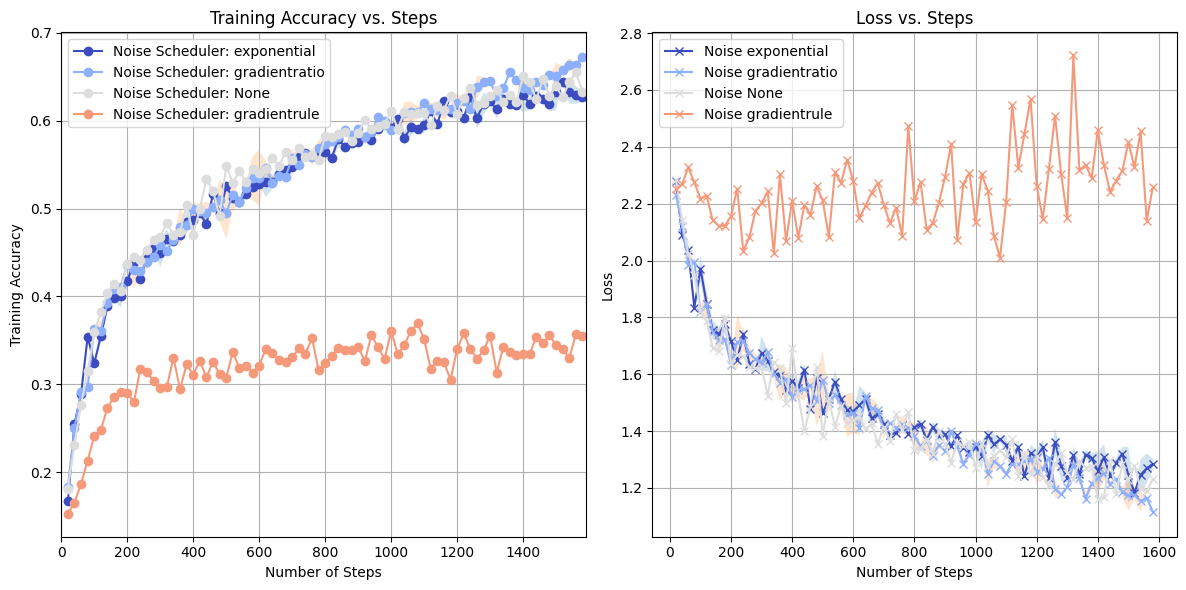

In [98]:
import matplotlib.pyplot as plt
import numpy as np

all_steps = []
all_train_acc = {}
all_loss = {}
scheduler_groups = {}

for idx in range(len(filtered_df)):
    experiment = filtered_df.iloc[idx]
    noise_scheduler = experiment["noise_scheduler"]
    training_steps = experiment["training_steps"]
    
    # Extract steps, train_acc, and loss for each experiment
    steps = [entry['nb_steps'] for entry in training_steps]
    train_acc = [entry['train_acc'] for entry in training_steps]
    loss = [entry['loss'] for entry in training_steps]
    
    # For each unique step, accumulate the train_acc and loss values grouped by ref_noise
    for step, acc, l in zip(steps, train_acc, loss):
        if step not in all_steps:
            all_steps.append(step)
        
        if noise_scheduler not in scheduler_groups:
            scheduler_groups[noise_scheduler] = {"train_acc": {}, "loss": {}}
        
        if step not in scheduler_groups[noise_scheduler]["train_acc"]:
            scheduler_groups[noise_scheduler]["train_acc"][step] = []
        if step not in scheduler_groups[noise_scheduler]["loss"]:
            scheduler_groups[noise_scheduler]["loss"][step] = []
        
        scheduler_groups[noise_scheduler]["train_acc"][step].append(acc)
        scheduler_groups[noise_scheduler]["loss"][step].append(l)

# Sort the steps (optional, depending on how the steps are ordered)
all_steps = sorted(all_steps)

all_steps = sorted([step for step in all_steps if step <= 1593])

# Create the plot
plt.figure(figsize=(12, 6))

from matplotlib import cm
colormap = cm.get_cmap("coolwarm", 5)
colors = [colormap(i) for i in range(5)]

col_idx = 0
# Loop through each ref_noise group and calculate mean and std, then plot
for noise_scheduler, group in scheduler_groups.items():
    mean_train_acc = []
    std_train_acc = []
    mean_loss = []
    std_loss = []
    
    # Calculate the mean and standard deviation for each step in this group
    for step in all_steps:
        mean_train_acc.append(np.mean(group["train_acc"].get(step, [0])))
        std_train_acc.append(np.std(group["train_acc"].get(step, [0])))
        mean_loss.append(np.mean(group["loss"].get(step, [0])))
        std_loss.append(np.std(group["loss"].get(step, [0])))
    
    # Plot training accuracy with shaded standard deviation
    plt.subplot(1, 2, 1)
    plt.plot(all_steps, mean_train_acc, label=f'Noise Scheduler: {noise_scheduler}', marker='o', color=colors[col_idx])
    
    plt.fill_between(all_steps, np.array(mean_train_acc) - np.array(std_train_acc), 
                     np.array(mean_train_acc) + np.array(std_train_acc), alpha=0.2)
    
    # Plot loss with shaded standard deviation
    plt.subplot(1, 2, 2)
    plt.plot(all_steps, mean_loss, label=f'Noise {noise_scheduler}', marker='x', color=colors[col_idx])
    col_idx +=1
    plt.fill_between(all_steps, np.array(mean_loss) - np.array(std_loss), 
                     np.array(mean_loss) + np.array(std_loss), alpha=0.2)

# Set labels, titles, and grids
plt.subplot(1, 2, 1)
plt.xlabel('Number of Steps')
plt.ylabel('Training Accuracy')
plt.xlim(0,1590)
plt.title('Training Accuracy vs. Steps')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.xlabel('Number of Steps')
plt.ylabel('Loss')
plt.title('Loss vs. Steps')
plt.grid(True)
plt.legend()

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()


- gradientrule underperforms in terms of accuracy, at a final value of 0.35 (compared to 0.1 with random guessing [insert dpsgd as a baseline here])
- gradientrule has trouble minimizing the training loss
- noise values of 5 and 6 seem to aggressive, inhibiting the training from progressing

- gradient ratio scheduler is able to effectively reduce the loss, performing similar to the baseline [insert values here!] 

- exponential decay is able to effectively reduce the training loss


/var/folders/9l/2lhc2hnd6px5hd0bxlsy1rh80000gn/T/ipykernel_90740/2069790478.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("coolwarm", 5)


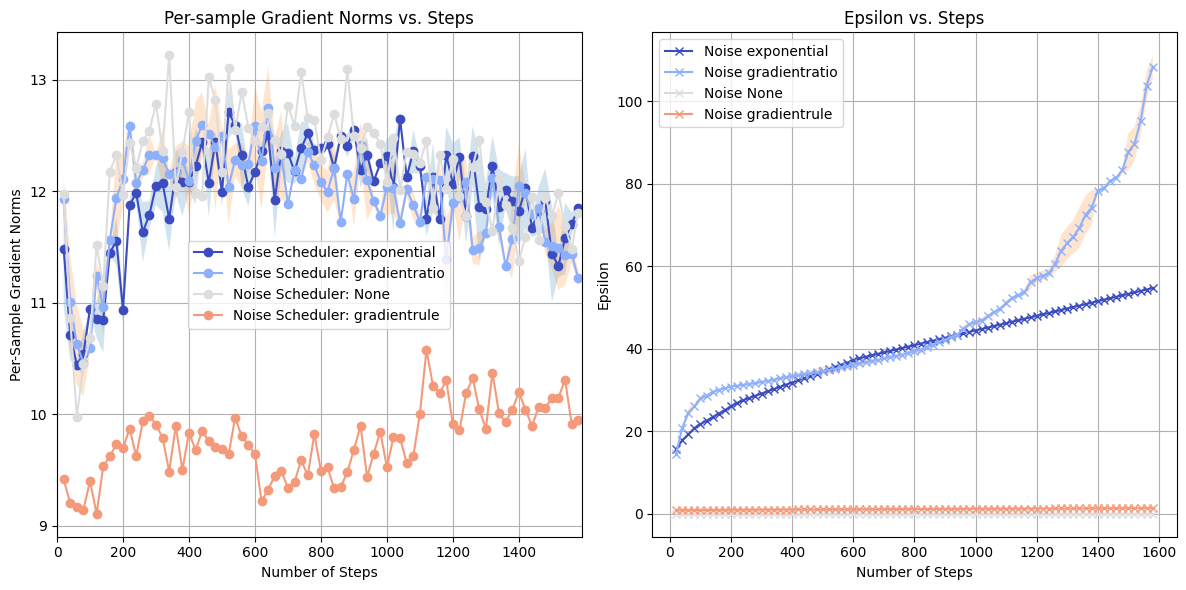

In [97]:
import matplotlib.pyplot as plt
import numpy as np

all_steps = []
all_train_acc = {}
all_epsilon = {}
scheduler_groups = {}

for idx in range(len(filtered_df)):
    experiment = filtered_df.iloc[idx]
    noise_scheduler = experiment["noise_scheduler"]
    training_steps = experiment["training_steps"]
    
    # Extract steps, train_acc, and epsilon for each experiment
    steps = [entry['nb_steps'] for entry in training_steps]
    grad_sample_gradients_norms = [entry['grad_sample_gradients_norms'] for entry in training_steps]
    epsilon = [entry['epsilon'] for entry in training_steps]
    
    # For each unique step, accumulate the train_acc and epsilon values grouped by ref_noise
    for step, acc, l in zip(steps, grad_sample_gradients_norms, epsilon):
        if step not in all_steps:
            all_steps.append(step)
        
        if noise_scheduler not in scheduler_groups:
            scheduler_groups[noise_scheduler] = {"grad_sample_gradients_norms": {}, "epsilon": {}}
        
        if step not in scheduler_groups[noise_scheduler]["grad_sample_gradients_norms"]:
            scheduler_groups[noise_scheduler]["grad_sample_gradients_norms"][step] = []
        if step not in scheduler_groups[noise_scheduler]["epsilon"]:
            scheduler_groups[noise_scheduler]["epsilon"][step] = []
        
        scheduler_groups[noise_scheduler]["grad_sample_gradients_norms"][step].append(acc)
        scheduler_groups[noise_scheduler]["epsilon"][step].append(l)

# Sort the steps (optional, depending on how the steps are ordered)
all_steps = sorted(all_steps)

all_steps = sorted([step for step in all_steps if step <= 1593])

# Create the plot
plt.figure(figsize=(12, 6))

from matplotlib import cm
colormap = cm.get_cmap("coolwarm", 5)
colors = [colormap(i) for i in range(5)]

color_idx=0

# Loop through each ref_noise group and calculate mean and std, then plot
for noise_scheduler, group in scheduler_groups.items():
    mean_grad_sample_gradients_norms = []
    std_grad_sample_gradients_norms = []
    mean_epsilon = []
    std_epsilon = []
    
    # Calculate the mean and standard deviation for each step in this group
    for step in all_steps:
        mean_grad_sample_gradients_norms.append(np.mean(group["grad_sample_gradients_norms"].get(step, [0])))
        std_grad_sample_gradients_norms.append(np.std(group["grad_sample_gradients_norms"].get(step, [0])))
        mean_epsilon.append(np.mean(group["epsilon"].get(step, [0])))
        std_epsilon.append(np.std(group["epsilon"].get(step, [0])))
    
    # Plot training accuracy with shaded standard deviation
    plt.subplot(1, 2, 1)
    plt.plot(all_steps, mean_grad_sample_gradients_norms, label=f'Noise Scheduler: {noise_scheduler}', marker='o', color=colors[color_idx])
    plt.fill_between(all_steps, np.array(mean_grad_sample_gradients_norms) - np.array(std_grad_sample_gradients_norms), 
                     np.array(mean_grad_sample_gradients_norms) + np.array(std_grad_sample_gradients_norms), alpha=0.2)
    
    # Plot epsilon with shaded standard deviation
    plt.subplot(1, 2, 2)
    plt.plot(all_steps, mean_epsilon, label=f'Noise {noise_scheduler}', marker='x', color=colors[color_idx])
    color_idx+=1
    plt.fill_between(all_steps, np.array(mean_epsilon) - np.array(std_epsilon), 
                     np.array(mean_epsilon) + np.array(std_epsilon), alpha=0.2)

# Set labels, titles, and grids
plt.subplot(1, 2, 1)
plt.xlabel('Number of Steps')
plt.ylabel('Per-Sample Gradient Norms')
plt.xlim(0,1590)
plt.title('Per-sample Gradient Norms vs. Steps')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.xlabel('Number of Steps')
plt.ylabel('Epsilon')
plt.title('Epsilon vs. Steps')
plt.grid(True)
plt.legend()

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()


- per sample gradients show a characteristic progression, with a warmup period of low per-sample gradients (until iterations 200), then a period of high gradients follows (200-1200 steps), finally resulting in a slow decay of the gradients, signalling the convergence of the training
- 